<a href="https://colab.research.google.com/github/the-chetan-dr/ATS-resume-guider/blob/main/sentimnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -U numpy pandas scikit-learn nltk spacy matplotlib seaborn joblib tensorflow --quiet
!python -m spacy download en_core_web_sm --quiet



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 110.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import spacy
nlp = spacy.load("en_core_web_sm")

import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("✅ spaCy and NLTK are ready to use!")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


✅ spaCy and NLTK are ready to use!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import spacy
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


In [ ]:
from google.colab import files
uploaded = files.upload()

KeyboardInterrupt: 

In [ ]:
import pandas as pd

# Load the Sentiment140 dataset you uploaded
df = pd.read_csv('/content/training.1600000.processed.noemoticon.csv',
                 encoding='latin-1',
                 names=['target', 'ids', 'date', 'flag', 'user', 'text'])

# Keep only necessary columns
df = df[['target', 'text']]

# Convert numeric labels to readable text
df['target'] = df['target'].replace({0: 'negative', 4: 'positive'})

print("✅ Data loaded successfully! Sample rows:")
df.head()


✅ Data loaded successfully! Sample rows:


,target,text
0,negative,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,negative,is upset that he can't update his Facebook by ...
2,negative,@Kenichan I dived many times for the ball. Man...
3,negative,my whole body feels itchy and like its on fire
4,negative,"@nationwideclass no, it's not behaving at all...."


In [ ]:
import pandas as pd

# Load your dataset
data = pd.read_csv('/content/training.1600000.processed.noemoticon.csv', encoding='latin-1', header=None)

# Add proper column names
data.columns = ['target', 'id', 'date', 'flag', 'user', 'text']

# Show first few rows
data.head()


,target,id,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [ ]:
import re
import nltk
import spacy
from nltk.corpus import stopwords

# Download stopwords
nltk.download('stopwords')

# Load English model for spaCy
nlp = spacy.load('en_core_web_sm')

stop_words = set(stopwords.words('english'))

def clean_tweet(text):
    # Remove URLs, mentions, hashtags, digits, and special characters
    text = re.sub(r'http\S+|www\S+|@\S+|#\S+|[^A-Za-z\s]', '', text)
    text = text.lower()

    # Lemmatize and remove stopwords
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc if token.text not in stop_words and token.is_alpha]
    return ' '.join(tokens)

# Apply to a small sample for testing (for speed)
data_sample = data.sample(10000, random_state=42)  # use 10,000 rows for now
data_sample['clean_text'] = data_sample['text'].apply(clean_tweet)

data_sample.head()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,target,id,date,flag,user,text,clean_text
541200,0,2200003196,Tue Jun 16 18:18:12 PDT 2009,NO_QUERY,LaLaLindsey0609,@chrishasboobs AHHH I HOPE YOUR OK!!!,ahhh hope ok
750,0,1467998485,Mon Apr 06 23:11:14 PDT 2009,NO_QUERY,sexygrneyes,"@misstoriblack cool , i have no tweet apps fo...",cool tweet app razr
766711,0,2300048954,Tue Jun 23 13:40:11 PDT 2009,NO_QUERY,sammydearr,@TiannaChaos i know just family drama. its la...,know family drama lamehey next time u hang kim...
285055,0,1993474027,Mon Jun 01 10:26:07 PDT 2009,NO_QUERY,Lamb_Leanne,School email won't open and I have geography ...,school email will not open geography stuff rev...
705995,0,2256550904,Sat Jun 20 12:56:51 PDT 2009,NO_QUERY,yogicerdito,upper airways problem,upper airway problem


In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Convert target labels: 0 = negative, 4 = positive → make them 0 and 1
data_sample['target'] = data_sample['target'].replace({4: 1})

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    data_sample['clean_text'], data_sample['target'],
    test_size=0.2, random_state=42
)

# Convert text to numerical form using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Train Naive Bayes model
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

# Predict on test data
y_pred = model.predict(X_test_tfidf)

# Evaluate
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


✅ Accuracy: 0.711

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.73      0.71       980
           1       0.73      0.69      0.71      1020

    accuracy                           0.71      2000
   macro avg       0.71      0.71      0.71      2000
weighted avg       0.71      0.71      0.71      2000



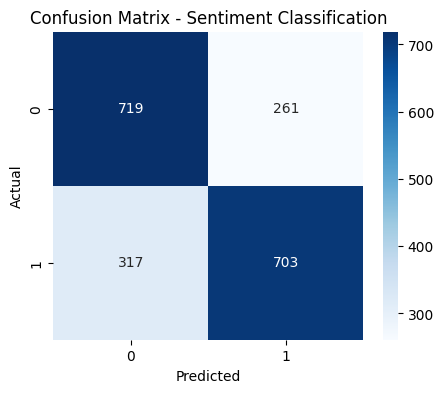

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Sentiment Classification")
plt.show()
